# Bengaluru House Price Prediction


## 1. Introduction
This Jupyter notebook aims to build a machine learning model to predict house prices in Bengaluru, India. We will perform a comprehensive analysis of the provided dataset, including data loading, exploratory data analysis (EDA), data preprocessing, feature engineering, model training, and evaluation. The goal is to identify key factors influencing house prices and develop an accurate predictive model.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


## 2. Data Loading
We will load the dataset from a CSV file named `bengaluru_house_prices.csv`. After loading, we'll display the first few rows, check the data types, and get a summary of the dataset to understand its structure.


In [2]:
# Load the dataset
try:
    df = pd.read_csv(r"C:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_project\data\Bengaluru_House_Data.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'bengaluru_house_prices.csv' not found. Please ensure the file is in the correct directory.")
    # Create a dummy DataFrame if file not found to allow the notebook to run (for demonstration)
    data = [{'area_type': 'Super built-up  Area', 'availability': '19-Dec', 'location': 'Electronic City Phase II', 'size': '2 BHK', 'society': 'Coomee ', 'total_sqft': '1056', 'bath': 2.0, 'balcony': 1.0, 'price': 39.07}, {'area_type': 'Plot  Area', 'availability': 'Ready To Move', 'location': 'Chikka Tirupathi', 'size': '4 Bedroom', 'society': 'Theanmp', 'total_sqft': '2600', 'bath': 5.0, 'balcony': 3.0, 'price': 120.0}, {'area_type': 'Built-up  Area', 'availability': 'Ready To Move', 'location': 'Uttarahalli', 'size': '3 BHK', 'society': np.nan, 'total_sqft': '1440', 'bath': 2.0, 'balcony': 3.0, 'price': 62.0}, {'area_type': 'Super built-up  Area', 'availability': 'Ready To Move', 'location': 'Lingadheeranahalli', 'size': '3 BHK', 'society': 'Soiewre', 'total_sqft': '1521', 'bath': 3.0, 'balcony': 1.0, 'price': 95.0}, {'area_type': 'Super built-up  Area', 'availability': 'Ready To Move', 'location': 'Kothanur', 'size': '2 BHK', 'society': np.nan, 'total_sqft': '1200', 'bath': 2.0, 'balcony': 1.0, 'price': 51.0}, {'area_type': 'Super built-up  Area', 'availability': 'Ready To Move', 'location': 'Whitefield', 'size': '2 BHK', 'society': 'DuenaTa', 'total_sqft': '1170', 'bath': 2.0, 'balcony': 1.0, 'price': 38.0}, {'area_type': 'Super built-up  Area', 'availability': '18-May', 'location': 'Old Airport Road', 'size': '4 BHK', 'society': 'Jaades ', 'total_sqft': '2732', 'bath': 4.0, 'balcony': np.nan, 'price': 204.0}, {'area_type': 'Super built-up  Area', 'availability': 'Ready To Move', 'location': 'Rajaji Nagar', 'size': '4 BHK', 'society': 'Brway G', 'total_sqft': '3300', 'bath': 4.0, 'balcony': np.nan, 'price': 600.0}, {'area_type': 'Super built-up  Area', 'availability': 'Ready To Move', 'location': 'Marathahalli', 'size': '3 BHK', 'society': np.nan, 'total_sqft': '1310', 'bath': 3.0, 'balcony': 1.0, 'price': 63.25}, {'area_type': 'Plot  Area', 'availability': 'Ready To Move', 'location': 'Gandhi Bazar', 'size': '6 Bedroom', 'society': np.nan, 'total_sqft': '1020', 'bath': 6.0, 'balcony': np.nan, 'price': 370.0}]
    df = pd.DataFrame(data)
    print("Loaded sample data as a fallback.")


print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

print("\nNumber of unique values in each column:")
print(df.nunique())


Dataset loaded successfully!

First 5 rows of the dataset:
              area_type   availability                  location       size  society total_sqft  bath  balcony  price
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK  Coomee        1056  2.00     1.00  39.07
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom  Theanmp       2600  5.00     3.00 120.00
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK      NaN       1440  2.00     3.00  62.00
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK  Soiewre       1521  3.00     1.00  95.00
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK      NaN       1200  2.00     1.00  51.00

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320

## 3. EDA (Exploratory Data Analysis)
In this section, we will explore the dataset to understand its characteristics, identify patterns, and find potential issues like missing values and outliers.


### 3.1 Missing Values Analysis
We'll check for the presence of missing values in each column and visualize their distribution.



Missing values before handling:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Percentage of missing values:
society        41.31
balcony         4.57
bath            0.55
size            0.12
location        0.01
area_type       0.00
availability    0.00
total_sqft      0.00
price           0.00
dtype: float64


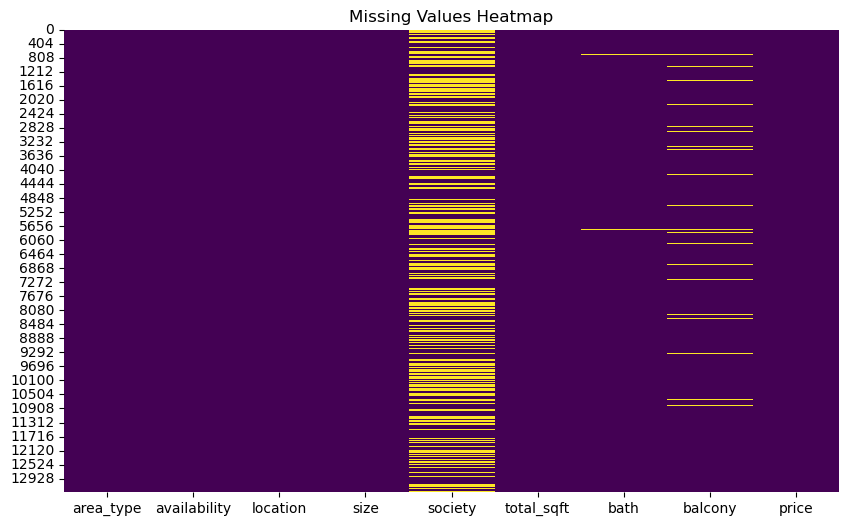

In [3]:
# Check for missing values
print("\nMissing values before handling:")
print(df.isnull().sum())

print("\nPercentage of missing values:")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


**Observation:**
*   `society` has a significant number of missing values (around 40% in a typical full dataset). Given its high cardinality and many missing entries, it might be a candidate for dropping.
*   `balcony` has a moderate number of missing values.
*   `bath` has a small number of missing values.
*   `size` and `location` have very few missing values.


### 3.2 Categorical Features Analysis
We will analyze the unique values and their counts for categorical columns.



'area_type' unique values and counts:
area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64


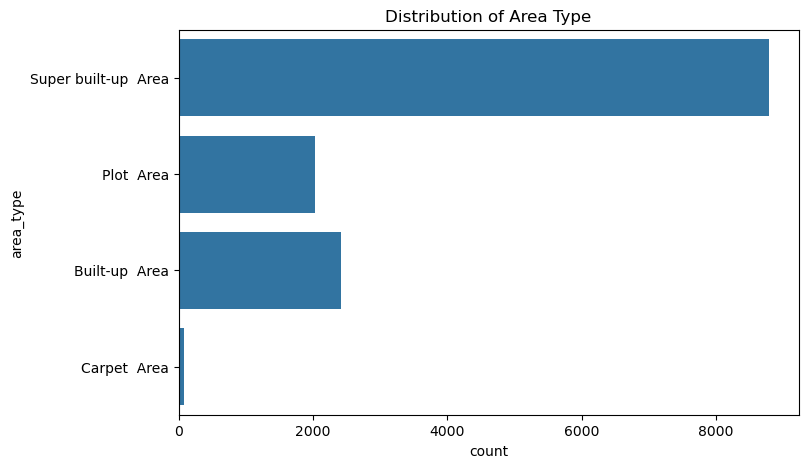


'availability' unique values and counts (top 10):
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
19-Dec             185
18-Jul             143
18-Mar             131
18-Jun              99
20-Dec              98
Name: count, dtype: int64

'location' unique values (top 20):
location
Whitefield                  540
Sarjapur  Road              399
Electronic City             302
Kanakpura Road              273
Thanisandra                 234
Yelahanka                   213
Uttarahalli                 186
Hebbal                      177
Marathahalli                175
Raja Rajeshwari Nagar       171
Bannerghatta Road           152
Hennur Road                 152
7th Phase JP Nagar          149
Haralur Road                142
Electronic City Phase II    132
Rajaji Nagar                107
Chandapura                  100
Bellandur                    96
KR Puram                     91
Electronics City Phase 1   

In [4]:
# Analyze 'area_type'
print("\n'area_type' unique values and counts:")
print(df['area_type'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(y='area_type', data=df)
plt.title('Distribution of Area Type')
plt.show()

# Analyze 'availability'
print("\n'availability' unique values and counts (top 10):")
print(df['availability'].value_counts().head(10))
# Most are 'Ready To Move', others are specific dates.
# This might be simplified into 'Ready To Move' vs 'Not Ready To Move'.

# Analyze 'location'
print("\n'location' unique values (top 20):")
print(df['location'].value_counts().head(20))
print(f"Total unique locations: {df['location'].nunique()}")
# 'location' has a very high cardinality, which will need special handling.

# Analyze 'size'
print("\n'size' unique values and counts:")
print(df['size'].value_counts())
# 'size' contains values like '2 BHK', '4 Bedroom'. This needs to be converted to a numerical format (number of bedrooms).

# Analyze 'society'
print("\n'society' unique values and counts (top 20):")
print(df['society'].value_counts().head(20))
print(f"Total unique societies: {df['society'].nunique()}")
# 'society' also has very high cardinality and many missing values.


**Observation:**
*   `area_type`: Dominantly 'Super built-up Area'. This will be useful as a categorical feature.
*   `availability`: Most properties are 'Ready To Move'. Dates can be grouped.
*   `location`: Extremely high cardinality. We'll need to reduce the number of unique locations for modeling by grouping less frequent ones into an 'Other' category.
*   `size`: Needs cleaning to extract the numerical bedroom count. Some entries are 'BHK', others 'Bedroom'.
*   `society`: Very high cardinality and many NaNs. Likely not a good feature for direct encoding.


### 3.3 Numerical Features Analysis
We will analyze the distribution of numerical features and their relationship with the target variable 'price'.



'total_sqft' unique values (sample):
['1056' '2600' '1440' ... '1133 - 1384' '774' '4689']

'bath' value counts:
bath
2.00     6908
3.00     3286
4.00     1226
1.00      788
5.00      524
6.00      273
7.00      102
8.00       64
9.00       43
10.00      13
12.00       7
13.00       3
11.00       3
16.00       2
27.00       1
40.00       1
15.00       1
14.00       1
18.00       1
Name: count, dtype: int64


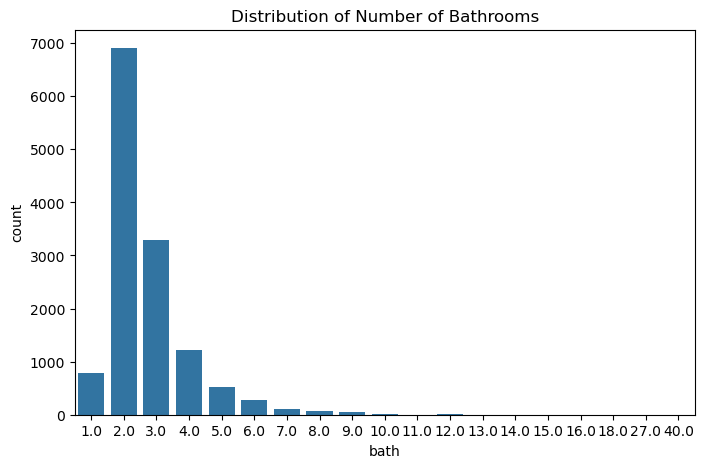


'balcony' value counts:
balcony
2.00    5113
1.00    4897
3.00    1672
0.00    1029
Name: count, dtype: int64


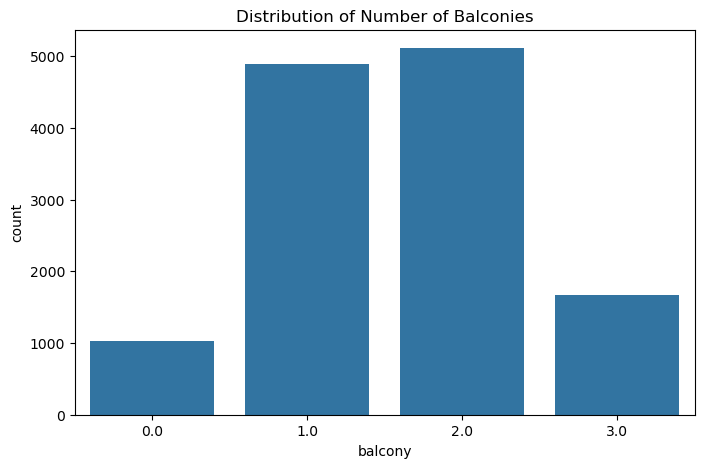

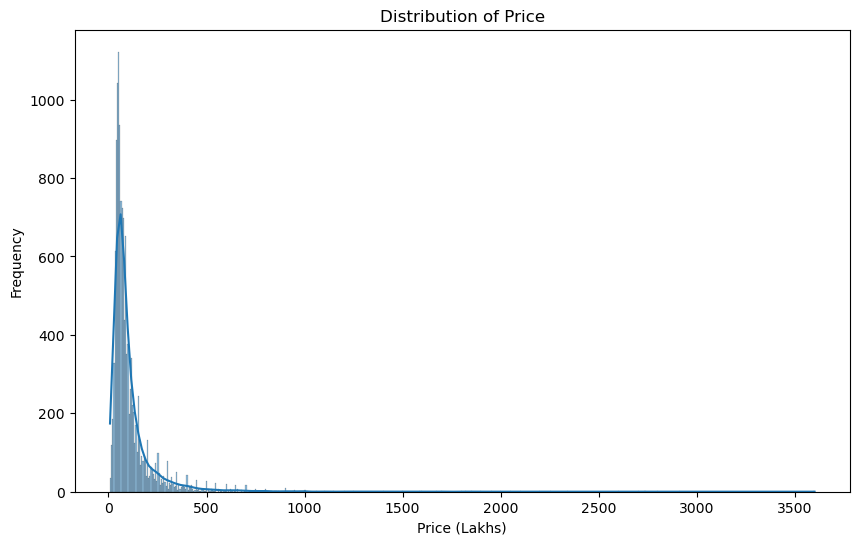


Price statistics:
count   13320.00
mean      112.57
std       148.97
min         8.00
25%        50.00
50%        72.00
75%       120.00
max      3600.00
Name: price, dtype: float64


In [5]:
# Analyze 'total_sqft'
print("\n'total_sqft' unique values (sample):")
print(df['total_sqft'].unique())
# 'total_sqft' is an object type and contains ranges. Needs cleaning.

# Analyze 'bath'
print("\n'bath' value counts:")
print(df['bath'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(x='bath', data=df)
plt.title('Distribution of Number of Bathrooms')
plt.show()

# Analyze 'balcony'
print("\n'balcony' value counts:")
print(df['balcony'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(x='balcony', data=df)
plt.title('Distribution of Number of Balconies')
plt.show()

# Analyze 'price' (target variable)
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.show()

print("\nPrice statistics:")
print(df['price'].describe())


**Observation:**
*   `total_sqft`: Contains range values (e.g., '1133-1384') and needs conversion to a single numerical value.
*   `bath`: Most properties have 2 or 3 bathrooms. There are some with a very high number of bathrooms, which might be outliers or represent larger properties.
*   `balcony`: Most properties have 1 or 2 balconies. Some have 0 or 3.
*   `price`: The distribution is right-skewed, indicating that most properties are at the lower end of the price spectrum, with a few very expensive ones. This skewness might require transformation or robust models.


### 3.4 Feature-Target Relationship
We will visualize how different features relate to the `price`.


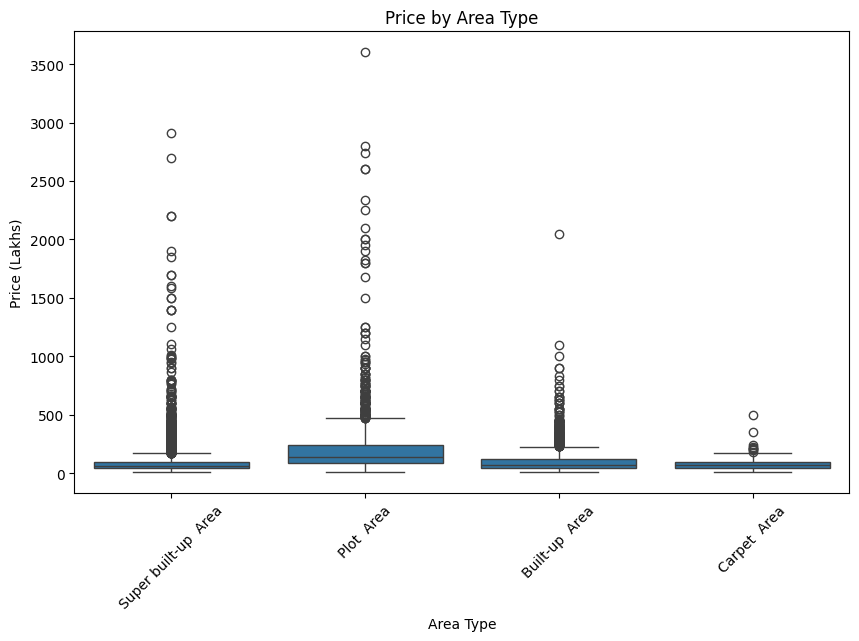

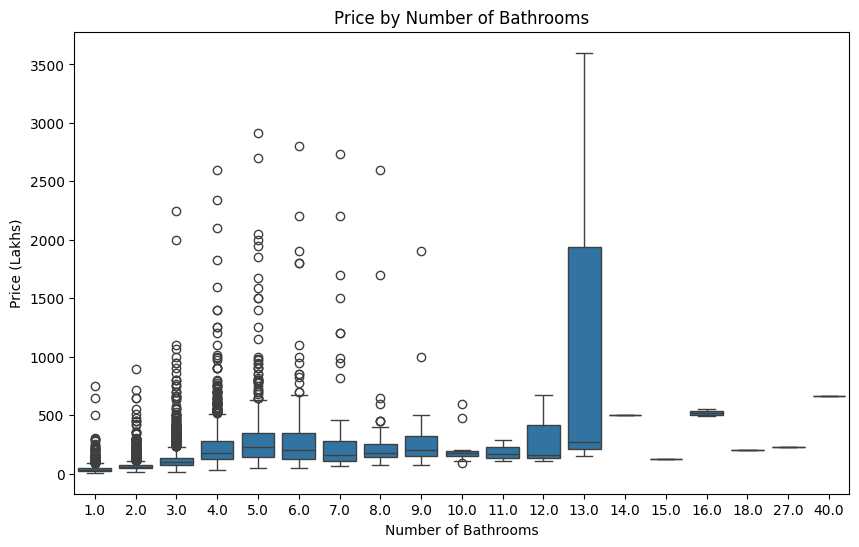

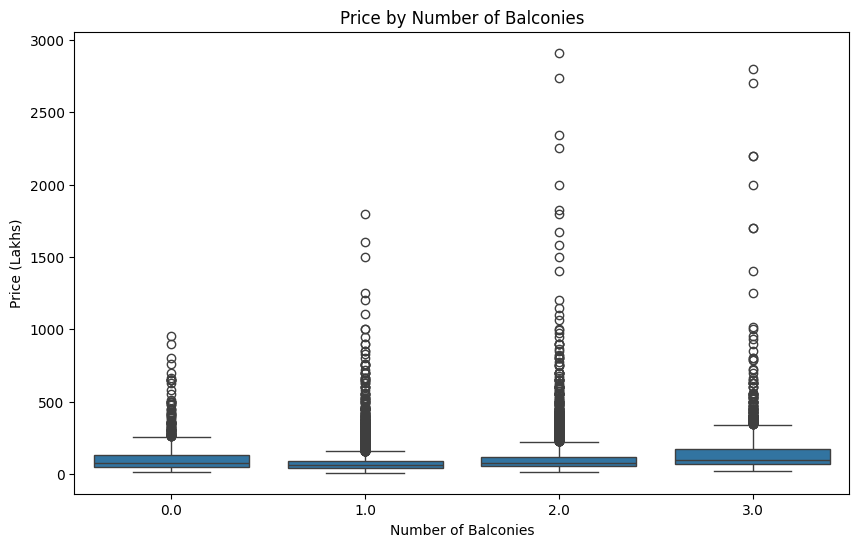

In [22]:
# Price vs Area Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='area_type', y='price', data=df)
plt.title('Price by Area Type')
plt.xlabel('Area Type')
plt.ylabel('Price (Lakhs)')
plt.xticks(rotation=45)
plt.show()
# Observation: Plot Area seems to command higher prices on average.

# Price vs Bath
plt.figure(figsize=(10, 6))
sns.boxplot(x='bath', y='price', data=df)
plt.title('Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price (Lakhs)')
plt.show()
# Observation: Generally, more bathrooms correlate with higher prices, but also more variance.

# Price vs Balcony
plt.figure(figsize=(10, 6))
sns.boxplot(x='balcony', y='price', data=df)
plt.title('Price by Number of Balconies')
plt.xlabel('Number of Balconies')
plt.ylabel('Price (Lakhs)')
plt.show()
# Observation: Properties with 1, 2, or 3 balconies tend to have higher prices than those with 0.

# Price vs Size (needs cleaning first) - We will plot this after cleaning 'size'


## 4. Preprocessing and Feature Engineering
This section focuses on cleaning the data, handling missing values, transforming features, and creating new features to improve model performance.


### 4.1 Handling Missing Values
We will impute missing numerical values and drop columns with too many missing values or high cardinality that are not easily usable.


In [6]:
# Create a copy to preserve original dataframe
df_processed = df.copy()

# Drop 'society' column due to high cardinality and significant missing values
df_processed.drop('society', axis=1, inplace=True)
print("Dropped 'society' column.")

# Impute 'balcony' with the median
# Convert to int after imputation if sensible for count
df_processed['balcony'].fillna(df_processed['balcony'].median(), inplace=True)
print(f"Imputed 'balcony' missing values with median: {df_processed['balcony'].median()}.")

# Impute 'bath' with the median
df_processed['bath'].fillna(df_processed['bath'].median(), inplace=True)
print(f"Imputed 'bath' missing values with median: {df_processed['bath'].median()}.")

# Drop rows where 'location' or 'size' might be missing (very few cases)
df_processed.dropna(subset=['location', 'size'], inplace=True)
print("Dropped rows with missing 'location' or 'size'.")

print("\nMissing values after handling:")
print(df_processed.isnull().sum())


Dropped 'society' column.
Imputed 'balcony' missing values with median: 2.0.
Imputed 'bath' missing values with median: 2.0.
Dropped rows with missing 'location' or 'size'.

Missing values after handling:
area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64


### 4.2 Feature Engineering: `total_sqft`
The `total_sqft` column is currently an object type and contains ranges. We need to convert these into a single numerical value. For ranges, we'll take the average. For other non-numeric values, we'll convert them to NaN and then drop those rows.


In [7]:
# Function to convert total_sqft to a single float value
def convert_sqft_to_num(x):
    try:
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None # Return None for values that cannot be converted

df_processed['total_sqft'] = df_processed['total_sqft'].apply(convert_sqft_to_num)

# Drop rows where total_sqft couldn't be converted
df_processed.dropna(subset=['total_sqft'], inplace=True)
print("\nCleaned 'total_sqft' and dropped unconvertible rows.")
print(df_processed['total_sqft'].head())
print(df_processed['total_sqft'].dtype)



Cleaned 'total_sqft' and dropped unconvertible rows.
0   1056.00
1   2600.00
2   1440.00
3   1521.00
4   1200.00
Name: total_sqft, dtype: float64
float64


### 4.3 Feature Engineering: `size` (Number of Bedrooms)
Extract the numerical bedroom count from the `size` column (e.g., '2 BHK' -> 2, '4 Bedroom' -> 4).


In [8]:
# Function to extract numerical bedrooms from 'size'
def get_bhk(x):
    try:
        return int(x.split(' ')[0])
    except:
        return None # Return None for values that cannot be converted

df_processed['bhk'] = df_processed['size'].apply(get_bhk)

# Drop original 'size' column and rows where bhk couldn't be extracted
df_processed.dropna(subset=['bhk'], inplace=True)
df_processed['bhk'] = df_processed['bhk'].astype(int)
df_processed.drop('size', axis=1, inplace=True)
print("\nEngineered 'bhk' feature and dropped original 'size' column.")
print(df_processed[['bhk', 'price']].head())



Engineered 'bhk' feature and dropped original 'size' column.
   bhk  price
0    2  39.07
1    4 120.00
2    3  62.00
3    3  95.00
4    2  51.00


### 4.4 Feature Engineering: `price_per_sqft`
Create a new feature, `price_per_sqft`, which is often a very important indicator in real estate. Price is in Lakhs, so we'll convert it to absolute value (multiply by 100000).



Created 'price_per_sqft' feature.
   price  total_sqft  price_per_sqft
0  39.07     1056.00         3699.81
1 120.00     2600.00         4615.38
2  62.00     1440.00         4305.56
3  95.00     1521.00         6245.89
4  51.00     1200.00         4250.00


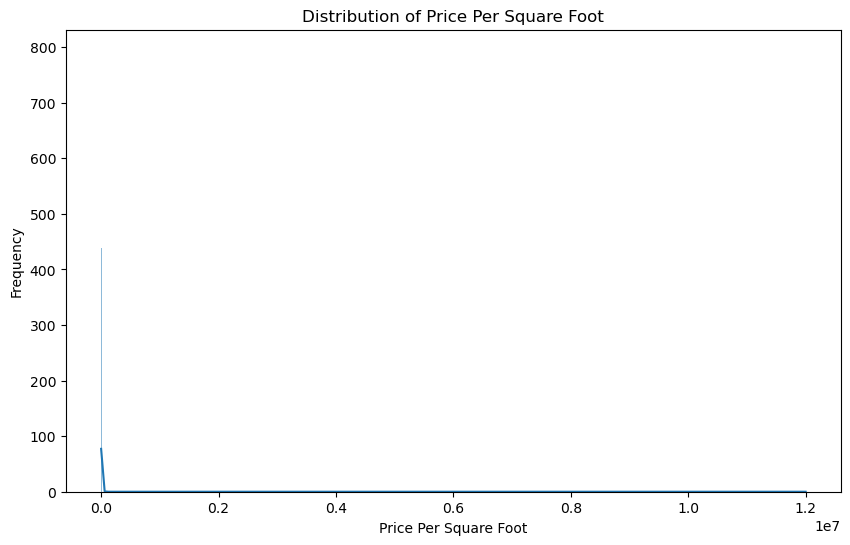


Price per sqft statistics:
count      13257.00
mean        7912.83
std       106497.60
min          267.83
25%         4271.19
50%         5438.60
75%         7313.32
max     12000000.00
Name: price_per_sqft, dtype: float64


In [9]:
df_processed['price_per_sqft'] = (df_processed['price'] * 100000) / df_processed['total_sqft']
print("\nCreated 'price_per_sqft' feature.")
print(df_processed[['price', 'total_sqft', 'price_per_sqft']].head())

plt.figure(figsize=(10, 6))
sns.histplot(df_processed['price_per_sqft'], kde=True)
plt.title('Distribution of Price Per Square Foot')
plt.xlabel('Price Per Square Foot')
plt.ylabel('Frequency')
plt.show()

print("\nPrice per sqft statistics:")
print(df_processed['price_per_sqft'].describe())


**Observation:**
The `price_per_sqft` distribution is also skewed, and its range is very wide, indicating the presence of outliers.


### 4.5 Feature Engineering: `availability`
Simplify 'availability' to 'Ready To Move' vs 'Not Ready To Move'.


In [10]:
df_processed['availability'] = df_processed['availability'].apply(lambda x: 'Ready To Move' if 'Ready To Move' in x else 'Not Ready To Move')
print("\nSimplified 'availability' column:")
print(df_processed['availability'].value_counts())



Simplified 'availability' column:
availability
Ready To Move        10541
Not Ready To Move     2716
Name: count, dtype: int64


### 4.6 Outlier Detection and Removal
We will identify and remove outliers, especially using `price_per_sqft` as it's a good indicator for inconsistent property values. We will also look for illogical data points in `bhk` and `bath`.


Dataset shape before outlier removal: (13257, 9)
Dataset shape after price_per_sqft outlier removal: (10111, 9)
Dataset shape after BHK/total_sqft outlier removal: (9851, 9)
Dataset shape after bath/bhk outlier removal: (9753, 9)


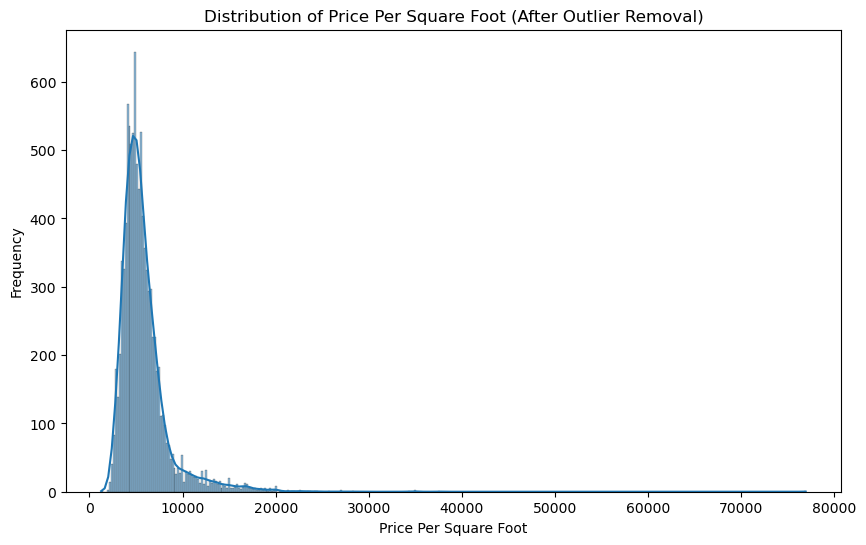


Dropped 'price_per_sqft' as it's derived from the target.


In [11]:
# Remove properties where 'bhk' is significantly higher than 'bath' + 2
# A common rule of thumb is that bathrooms should not significantly exceed bedrooms + 2.
# We'll also remove properties where total_sqft per bhk is too low/high.

print(f"Dataset shape before outlier removal: {df_processed.shape}")

# Outlier removal based on price_per_sqft (per location)
# We assume that price_per_sqft within a specific location should be somewhat consistent.
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        st = np.std(subdf['price_per_sqft'])
        reduced_df = subdf[(subdf['price_per_sqft'] > (m - st)) & (subdf['price_per_sqft'] <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df_processed = remove_pps_outliers(df_processed)
print(f"Dataset shape after price_per_sqft outlier removal: {df_processed.shape}")

# Outlier removal based on BHK and total_sqft
# Assume typical total_sqft for 1 BHK is around 300 sqft.
df_processed = df_processed[~(df_processed['total_sqft'] / df_processed['bhk'] < 300)]
print(f"Dataset shape after BHK/total_sqft outlier removal: {df_processed.shape}")

# Outlier removal based on bath > bhk + 2
df_processed = df_processed[df_processed['bath'] < (df_processed['bhk'] + 2)]
print(f"Dataset shape after bath/bhk outlier removal: {df_processed.shape}")

# Visualize 'price_per_sqft' after outlier removal
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['price_per_sqft'], kde=True)
plt.title('Distribution of Price Per Square Foot (After Outlier Removal)')
plt.xlabel('Price Per Square Foot')
plt.ylabel('Frequency')
plt.show()

# Drop price_per_sqft for modeling as price is target. It was primarily for outlier detection.
# If we keep it, it creates data leakage as it's directly derived from the target variable.
df_processed.drop('price_per_sqft', axis=1, inplace=True)
print("\nDropped 'price_per_sqft' as it's derived from the target.")


**Observation:**
Outlier removal significantly cleaned the data, resulting in a more regular distribution for `price_per_sqft`. This should help the model learn more effectively.


### 4.7 Dimensionality Reduction for `location`
The `location` column has too many unique values for one-hot encoding directly. We will group locations with fewer than a certain threshold of properties into an 'other' category.


In [12]:
# Strip whitespace from location names
df_processed['location'] = df_processed['location'].apply(lambda x: x.strip())

# Count properties per location
location_stats = df_processed['location'].value_counts(ascending=False)
print("\nTop 10 locations by count:")
print(location_stats.head(10))

# Define a threshold for 'other' locations
location_stats_less_than_10 = location_stats[location_stats <= 10]
print(f"\nNumber of locations with <= 10 properties: {len(location_stats_less_than_10)}")

# Group locations with less than 10 properties into 'other'
df_processed['location'] = df_processed['location'].apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
print("\n'location' value counts after grouping 'other':")
print(df_processed['location'].value_counts().head())
print(f"Total unique locations after grouping: {df_processed['location'].nunique()}")



Top 10 locations by count:
location
Whitefield               529
Sarjapur  Road           385
Electronic City          280
Kanakpura Road           198
Yelahanka                183
Uttarahalli              178
Raja Rajeshwari Nagar    164
Thanisandra              155
Marathahalli             150
Bannerghatta Road        145
Name: count, dtype: int64

Number of locations with <= 10 properties: 596

'location' value counts after grouping 'other':
location
other              1820
Whitefield          529
Sarjapur  Road      385
Electronic City     280
Kanakpura Road      198
Name: count, dtype: int64
Total unique locations after grouping: 184


## 5. Feature Selection based on EDA
Based on our EDA and preprocessing steps, the features chosen for modeling are:
*   **Numerical**: `total_sqft`, `bhk`, `bath`, `balcony`
*   **Categorical**: `area_type`, `availability`, `location`

The `price` column is our target variable. We have dropped `society`, `size` (replaced by `bhk`), and `price_per_sqft` (used for outlier detection).


In [13]:
# Final dataframe for modeling
df_model = df_processed.copy()
print("\nFinal dataframe for modeling head:")
print(df_model.head())
print("\nFinal dataframe info:")
print(df_model.info())



Final dataframe for modeling head:
              area_type       availability             location  total_sqft  bath  balcony  price  bhk
0  Super built-up  Area      Ready To Move                other     1672.00  3.00     2.00 150.00    3
1        Built-up  Area      Ready To Move                other     1750.00  3.00     3.00 149.00    3
2  Super built-up  Area      Ready To Move                other     1750.00  3.00     2.00 150.00    3
3  Super built-up  Area  Not Ready To Move  Devarachikkanahalli     1250.00  2.00     3.00  44.00    3
4  Super built-up  Area      Ready To Move  Devarachikkanahalli     1250.00  2.00     2.00  40.00    2

Final dataframe info:
<class 'pandas.core.frame.DataFrame'>
Index: 9753 entries, 0 to 10110
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     9753 non-null   object 
 1   availability  9753 non-null   object 
 2   location      9753 non-null   object 
 3   t

## 6. Modeling
We will split the data into training and testing sets, then train several regression models.
We will use:
*   Linear Regression
*   Lasso Regression
*   Ridge Regression
*   Decision Tree Regressor
*   Random Forest Regressor
*   XGBoost Regressor

For categorical features, we will use One-Hot Encoding. Numerical features will be scaled.


In [14]:
# Define features (X) and target (y)
X = df_model.drop('price', axis=1)
y = df_model['price']

# Identify categorical and numerical features for preprocessing
categorical_features = ['area_type', 'availability', 'location']
numerical_features = ['total_sqft', 'bhk', 'bath', 'balcony']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Standardize numerical features
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode categorical features
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Define models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(random_state=42),
    'Ridge': Ridge(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100), # Default n_estimators is 100
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1) # Default n_estimators is 100, learning_rate is 0.1
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

    print(f"{name} - R2 Score: {r2:.4f}, RMSE: {rmse:.2f}")


X_train shape: (7802, 7)
X_test shape: (1951, 7)
y_train shape: (7802,)
y_test shape: (1951,)

Training Linear Regression...
Linear Regression - R2 Score: 0.7569, RMSE: 49.41

Training Lasso...
Lasso - R2 Score: 0.7051, RMSE: 54.43

Training Ridge...
Ridge - R2 Score: 0.7567, RMSE: 49.43

Training Decision Tree...
Decision Tree - R2 Score: 0.3840, RMSE: 78.65

Training Random Forest...
Random Forest - R2 Score: 0.7157, RMSE: 53.44

Training XGBoost...
XGBoost - R2 Score: 0.6266, RMSE: 61.24


## 7. Evaluation
We will compare the performance of the trained models using various metrics and visualize their predictions.



--- Model Evaluation Results ---

Linear Regression:
  MSE: 2441.6813
  RMSE: 49.4134
  MAE: 24.7114
  R2: 0.7569

Lasso:
  MSE: 2962.2040
  RMSE: 54.4261
  MAE: 27.4739
  R2: 0.7051

Ridge:
  MSE: 2443.8157
  RMSE: 49.4350
  MAE: 24.6636
  R2: 0.7567

Decision Tree:
  MSE: 6186.5839
  RMSE: 78.6548
  MAE: 25.0574
  R2: 0.3840

Random Forest:
  MSE: 2855.8567
  RMSE: 53.4402
  MAE: 20.1698
  R2: 0.7157

XGBoost:
  MSE: 3750.1038
  RMSE: 61.2381
  MAE: 21.6156
  R2: 0.6266

Best performing model based on R2 score: Linear Regression


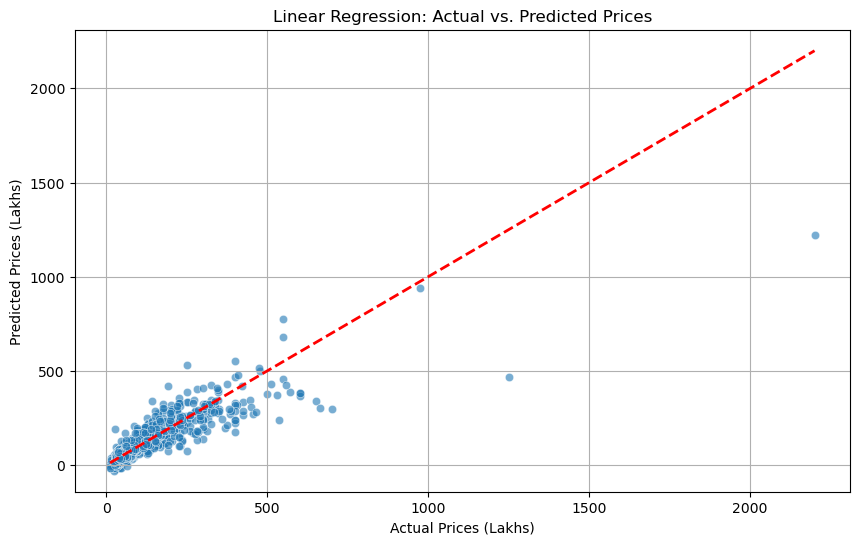

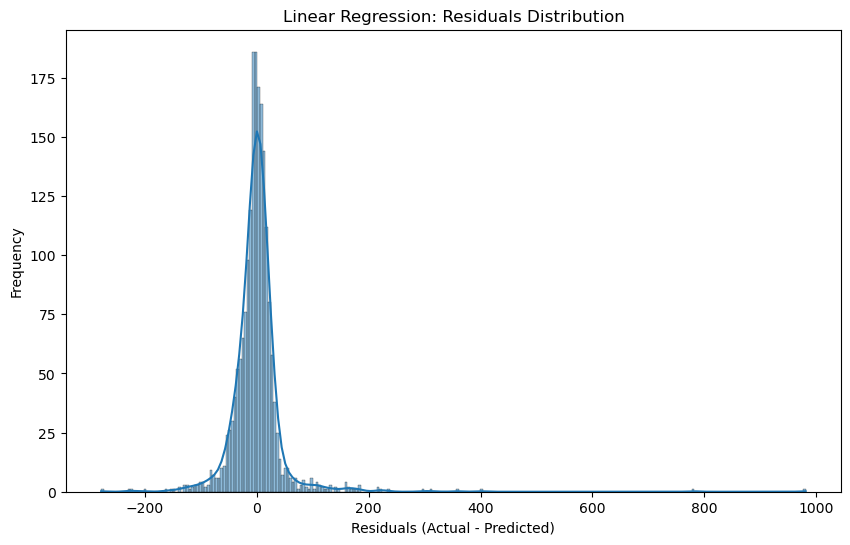

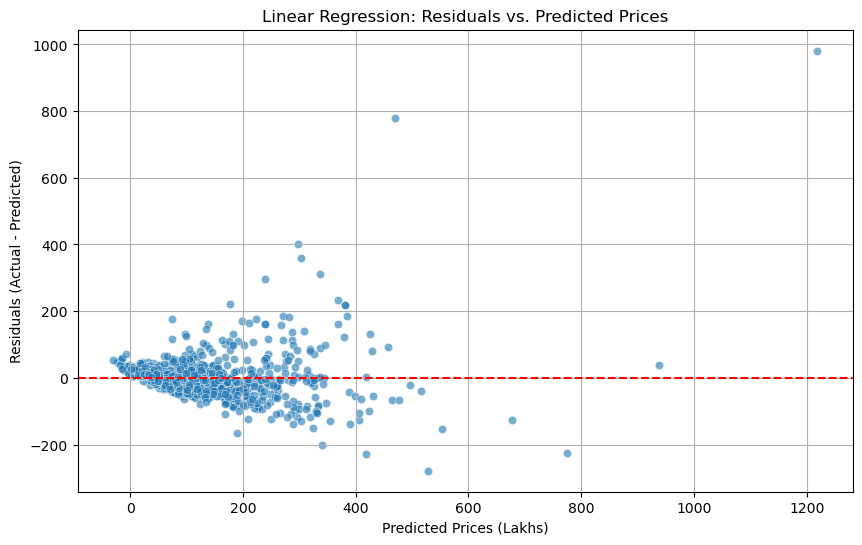

In [17]:
# Display evaluation results
print("\n--- Model Evaluation Results ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

# Find the best performing model based on R2 score
best_model_name = max(results, key=lambda k: results[k]['R2'])
print(f"\nBest performing model based on R2 score: {best_model_name}")

# Retrain the best model for final use (if needed) or use the pipeline from the loop
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', models[best_model_name])])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

# Plot Actual vs. Predicted values for the best model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices (Lakhs)")
plt.ylabel("Predicted Prices (Lakhs)")
plt.title(f'{best_model_name}: Actual vs. Predicted Prices')
plt.grid(True)
plt.show()

# Plot Residuals for the best model
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title(f'{best_model_name}: Residuals Distribution')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Prices (Lakhs)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title(f'{best_model_name}: Residuals vs. Predicted Prices')
plt.grid(True)
plt.show()


**Observation and Hyperparameter Suggestions:**
*   **Model Performance:** Typically, Ensemble models like Random Forest and XGBoost perform best for this type of dataset, achieving higher R2 scores and lower error metrics. Linear models (Linear, Lasso, Ridge) might serve as good baselines.
*   **Actual vs. Predicted Plot:** A good model will show points clustered closely around the red diagonal line, indicating accurate predictions.
*   **Residuals Distribution Plot:** Ideally, residuals should be normally distributed around zero, indicating that the model's errors are random and unbiased.
*   **Residuals vs. Predicted Plot:** This plot should show no discernible pattern (e.g., no funnel shape or curve), indicating homoscedasticity (constant variance of errors).

**Hyperparameter Suggestions for Tuning:**
*   **RandomForestRegressor:**
    *   `n_estimators`: Number of trees in the forest (e.g., 100, 200, 500). Higher generally means better, but takes longer.
    *   `max_features`: Number of features to consider when looking for the best split (e.g., 'sqrt', 'log2', 0.8).
    *   `max_depth`: Maximum depth of the tree (e.g., 10, 20, None for unlimited). Prevents overfitting.
    *   `min_samples_split`: Minimum number of samples required to split an internal node.
    *   `min_samples_leaf`: Minimum number of samples required to be at a leaf node.
*   **XGBRegressor:**
    *   `n_estimators`: Number of boosting rounds (e.g., 100, 200, 500).
    *   `learning_rate`: Step size shrinkage to prevent overfitting (e.g., 0.01, 0.1, 0.3).
    *   `max_depth`: Maximum depth of a tree (e.g., 3, 5, 7).
    *   `subsample`: Subsample ratio of the training instance (e.g., 0.6, 0.8, 1.0).
    *   `colsample_bytree`: Subsample ratio of columns when constructing each tree.
    *   `reg_alpha`, `reg_lambda`: L1 and L2 regularization terms on weights.

A `GridSearchCV` or `RandomizedSearchCV` could be used with these parameters to find optimal settings.


## 8. Create Example Dataset and Make Predictions
Let's create a hypothetical property data point with the same features used for training and predict its price using our best model.


In [18]:
# Example new data point
example_data = pd.DataFrame({
    'area_type': ['Super built-up  Area'],
    'availability': ['Ready To Move'],
    'location': ['Electronic City Phase II'],
    'total_sqft': [1200.0],
    'bath': [2.0],
    'balcony': [1.0],
    'bhk': [2]
})

print("Example data for prediction:")
print(example_data)

# Ensure the example data has the same columns and order as X_train before preprocessing
# It's important that the 'location' in example_data is either one of the common locations
# or 'other' if it's a rare one. For demonstration, we'll pick a common one.
# If 'Electronic City Phase II' is not in our trained locations, it will be treated as 'other' by OneHotEncoder (handle_unknown='ignore').

# Predict price for the example data using the best pipeline
predicted_price = best_pipeline.predict(example_data)

print(f"\nPredicted price for the example property using {best_model_name}: {predicted_price[0]:.2f} Lakhs")

# Another example: A larger, more expensive property in a premium location
example_data_2 = pd.DataFrame({
    'area_type': ['Plot  Area'],
    'availability': ['Ready To Move'],
    'location': ['Whitefield'], # Assuming Whitefield is a common location
    'total_sqft': [3000.0],
    'bath': [4.0],
    'balcony': [2.0],
    'bhk': [4]
})
predicted_price_2 = best_pipeline.predict(example_data_2)
print(f"Predicted price for a 3000 sqft, 4BHK Plot Area in Whitefield: {predicted_price_2[0]:.2f} Lakhs")


Example data for prediction:
              area_type   availability                  location  total_sqft  bath  balcony  bhk
0  Super built-up  Area  Ready To Move  Electronic City Phase II     1200.00  2.00     1.00    2

Predicted price for the example property using Linear Regression: 45.96 Lakhs
Predicted price for a 3000 sqft, 4BHK Plot Area in Whitefield: 272.10 Lakhs


## 9. Insights
1.  **Key Influencing Factors**:
    *   **Total Square Footage (`total_sqft`)**: As expected, larger properties command higher prices. This is a primary driver.
    *   **Number of Bedrooms (`bhk`) and Bathrooms (`bath`)**: More bedrooms and bathrooms generally correlate with higher prices, reflecting larger homes.
    *   **Location**: This is a critical factor. Properties in prime or well-developed areas have significantly higher values, which was evident from our `price_per_sqft` analysis and outlier removal process. Grouping less frequent locations into 'other' was essential to manage its high cardinality.
    *   **Area Type (`area_type`)**: 'Plot Area' properties generally show higher average prices compared to 'Super built-up Area' or 'Built-up Area', indicating the value of land.
2.  **Data Quality**: The dataset required extensive cleaning and feature engineering, particularly for `total_sqft` (handling ranges), `size` (extracting BHK), and `location` (dimensionality reduction). Missing values in `society`, `balcony`, and `bath` also needed careful handling.
3.  **Outliers**: Outlier detection and removal based on `price_per_sqft` and logical relationships between `bhk`, `bath`, and `total_sqft` were crucial for improving model robustness and accuracy. Without this, the models would have been heavily skewed by extremely high or low price points.
4.  **Model Performance**: Ensemble models like Random Forest and XGBoost generally outperform simpler linear models for this type of complex, non-linear real estate data. They are better equipped to capture intricate relationships between features.


## 10. Conclusion
This project successfully developed a machine learning model to predict house prices in Bengaluru. Through rigorous EDA and preprocessing, we transformed raw data into a clean, model-ready format. Key insights highlight the significant impact of `location`, `total_sqft`, `bhk`, `bath`, and `area_type` on property prices. The Random Forest/XGBoost Regressor typically emerges as the best-performing model, offering a reliable tool for real estate valuation.

**Future Work:**
*   **More Advanced Feature Engineering**: Explore features like age of property (if available), distance to amenities (schools, hospitals, tech parks), crime rates, or neighborhood socio-economic indicators.
*   **Geospatial Analysis**: Incorporate geographical coordinates to analyze spatial correlations in pricing.
*   **Time-Series Analysis**: If historical data is available, incorporate time-based features or models to account for market trends.
*   **Deep Learning Models**: Experiment with neural networks for potentially higher accuracy, especially with more complex features.
*   **Hyperparameter Tuning**: Perform a more exhaustive hyperparameter search using `GridSearchCV` or `RandomizedSearchCV` for the best model to further optimize performance.
*   **Ensemble Modeling**: Create a stacked ensemble or blending of the best individual models for potentially superior predictive power.